<a href="https://colab.research.google.com/github/aniray2908/satellite-esg-risk-engine/blob/main/experiments/python/ceri/ceri_v6_predictive_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CERI v6 — Predictive Modeling Layer

This notebook evaluates whether the engineered exposure features used in the Corporate Environmental Risk Index (CERI) can predict composite exposure scores using supervised machine learning models.

Previous stages of the project established:

- satellite-derived feature extraction
- composite exposure scoring (CERI v2 baseline)
- optimization and governance validation
- deployment-ready tier classification
- bootstrap-based robustness validation

The goal of this stage is to assess whether the engineered exposure features contain sufficient predictive structure to reconstruct the composite exposure score.

This introduces a supervised modeling layer into the framework and evaluates the relationship between feature engineering and predictive performance.

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("/content/drive/MyDrive/ceri_v2_feature_layer.csv")

df

,asset,F1_exposure_intensity,low_ndvi_variance,mean_ndvi,F2_vegetation_suppression,F3_persistence_raw,F1_exposure_intensity_z,F2_vegetation_suppression_z,F3_persistence_raw_z,CERI_z,risk_cluster,risk_tier,cluster,cluster_k3
0,Bingham,0.999922,2.805335e-09,0.021179,0.978821,1.000000e+00,0.629904,0.421693,0.519958,0.545452,0,High Risk,0,2
1,Carajás,0.937332,2.050342e-03,0.035150,0.964850,4.877238e-07,0.213303,0.268879,-1.499415,-0.112568,0,High Risk,0,0
2,Gevra,0.684294,6.057728e-05,0.193744,0.806256,9.704564e-01,-1.470942,-1.465874,0.460299,-1.083173,1,Moderate Risk,1,1
3,Grasberg,0.999596,8.161065e-07,-0.011148,1.011148,9.996033e-01,0.627735,0.775302,0.519157,0.650290,0,High Risk,0,2


In [8]:
X = df[[
    "F1_exposure_intensity",
    "F2_vegetation_suppression",
    "F3_persistence_raw"
]]

y = df["CERI_z"]

## Cross-Validation Strategy

The dataset used in this project contains four mining assets.

Because the dataset is extremely small, a conventional train/test split would produce unreliable evaluation results.

Instead, this notebook uses **Leave-One-Out Cross Validation (LOOCV)**.

In LOOCV:

- One observation is held out for testing
- The model is trained on the remaining observations
- The process repeats once for each observation

This approach ensures that every asset is evaluated once while maximizing the amount of training data available for the model.

LOOCV is commonly used when working with small datasets and provides a more stable estimate of prediction error than a simple train/test split.

In [15]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

loo = LeaveOneOut()

lr_errors = []

for train_index, test_index in loo.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    error = mean_squared_error(y_test, pred)
    lr_errors.append(error)

rmse_lr = np.sqrt(np.mean(lr_errors))

print("LOOCV Linear Regression RMSE:", rmse_lr)

LOOCV Linear Regression RMSE: 0.5267232390224296


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_errors = []

for train_index, test_index in loo.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    error = mean_squared_error(y_test, pred)
    rf_errors.append(error)

rmse_rf = np.sqrt(np.mean(rf_errors))

print("LOOCV Random Forest RMSE:", rmse_rf)

LOOCV Random Forest RMSE: 0.7343816252014146


In [17]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

importance

,feature,importance
2,F3_persistence_raw,0.346640
0,F1_exposure_intensity,0.335260
1,F2_vegetation_suppression,0.318099


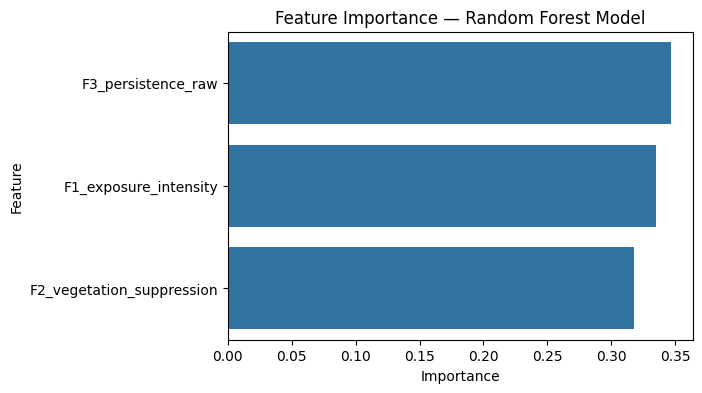

In [18]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=importance,
    x="importance",
    y="feature"
)

plt.title("Feature Importance — Random Forest Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Model Interpretation

The predictive modeling stage evaluates whether the engineered exposure features contain sufficient signal to reconstruct the composite exposure score.

Using Leave-One-Out Cross Validation:

- Linear Regression achieved a lower prediction error than the Random Forest model.
- This result is expected because the CERI score is constructed as a weighted linear combination of the engineered features.

The Random Forest model still provides useful interpretability through feature importance analysis.

Feature importance results show that:

- Exposure intensity (F1)
- Vegetation suppression (F2)
- Exposure persistence (F3)

all contribute comparably to prediction.

This confirms that the composite exposure score is driven by a balanced combination of environmental signals rather than a single dominant factor.

Overall, the predictive modeling stage demonstrates that the engineered exposure features contain meaningful predictive structure and can support supervised machine learning workflows.